<h1 style="text-align: center; font-weight: bold;">
بِسْمِ ٱللَّٰهِ ٱلرَّحْمَٰنِ ٱلرَّحِيمِ
</h1>

Full Name: Mohammadmahdi Bababeyk

Student ID: 4041419005

# Sentiment Analysis with BERT

**Sentiment analysis** is a core Natural Language Processing (NLP) task aimed at automatically identifying and extracting subjective information—such as opinions, emotions, or attitudes—from textual data. In its most common form (binary sentiment classification), the goal is to classify a piece of text (e.g., a movie review or product feedback) as expressing *positive* or *negative* sentiment. This has wide applications in social media monitoring, customer feedback analysis, market research, and more.

In this pipeline, we fine-tune **BERT (Bidirectional Encoder Representations from Transformers)**—a state-of-the-art language model developed by Google—for sentiment classification on the **IMDB movie reviews dataset**, which contains 50,000 highly polarized reviews labeled as *positive* or *negative*. BERT excels at such tasks because it uses deep bidirectional context: unlike traditional word embeddings (e.g., Word2Vec), it understands the meaning of a word based on *all* surrounding words—both left and right—in a sentence. By fine-tuning BERT on labeled sentiment data, we adapt its general language understanding to the specific domain of sentiment polarity detection, achieving high accuracy with minimal task-specific architecture changes.

## **0. Imports and Hyperparameters**

In [1]:
!pip install -qq transformers datasets torch scikit-learn numpy pandas matplotlib seaborn

import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Set seeds for reproducibility
set_seed(42)
torch.manual_seed(42)

#  Paths & Config
MODEL_NAME = "bert-base-uncased"
DATASET_NAME = "imdb"  # Binary sentiment: pos/neg reviews
OUTPUT_DIR = "./bert-sentiment-imdb"
BATCH_SIZE = 16
EPOCHS = 3
MAX_LENGTH = 128

2026-02-11 16:27:31.235884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770827251.568024      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770827251.675441      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770827252.506872      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770827252.506929      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770827252.506933      55 computation_placer.cc:177] computation placer alr

## **1. Loading & Preprocessing Data**

We begin by loading the `imdb` dataset from Hugging Face’s `datasets` library, which provides cleanly formatted training and test splits. The text is then tokenized using the `bert-base-uncased` tokenizer, which converts raw strings into token IDs, attention masks, and truncates sequences to a maximum length of 128 tokens (sufficient for short reviews). Dynamic padding is handled during batching via `DataCollatorWithPadding`, optimizing GPU memory usage and training speed.

In [2]:
dataset = load_dataset(DATASET_NAME)

# Use 10% of train as validation for faster demo (or use dataset['test'] for final eval)
# Here we split train → train/val, keep original test untouched
train_testvalid = dataset["train"].train_test_split(test_size=0.1, seed=42)
train_dataset = train_testvalid['train']
val_dataset = train_testvalid['test']
test_dataset = dataset['test']  # untouched test set

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: 22500, Val: 2500, Test: 25000


### Practice 1: Complete the tokenizer part

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],          # key in dataset dict containing input text
        truncation=True,         # boolean: whether to truncate sequences
        padding=False,            # typically False here — why? (A) saves memory (B) DataCollator handles it (C) avoids bugs
        max_length=MAX_LENGTH
    )

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [4]:
# Tokenize datasets
train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

## **2. Model & Training Setup**

We initialize a pre-trained `bert-base-uncased` model for sequence classification with two output labels (`NEGATIVE` = 0, `POSITIVE` = 1). The model retains BERT’s 12-layer Transformer encoder and adds a lightweight classification head (a single linear layer) on top. Training is configured via `TrainingArguments`: we use a low learning rate (2e-5) appropriate for fine-tuning, train for 3 epochs, and enable early stopping by loading the best checkpoint based on validation. The `Trainer` API handles the training loop, evaluation, logging, and checkpointing, while custom `compute_metrics` function reports accuracy, precision, recall, and F1 after each epoch.

### Practice 2: Complete the `model`

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,  # Fill in: how many classes for binary sentiment?
    id2label={0: "NEGATIVE", 1: "POSITIVE"},  # Map label IDs → names
    label2id={"NEGATIVE": 0, "POSITIVE": 1}   # Map names → IDs (ensure consistency!)
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
# Metrics function for Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

### Practice 3: Complete the training_args

In [7]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,  # directory to save checkpoints/logs
    eval_strategy="epoch",   # (A) "steps" (B) "epoch" (C) "no" — what ensures eval per epoch?
    save_strategy="epoch",   # should match eval_strategy for best model loading
    learning_rate=2e-5,   # typical fine-tuning LR for BERT-like models (~1e-5 to 5e-5)
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,    # common value to prevent overfitting
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=100,   # log every N steps (e.g., 100)
    load_best_model_at_end=True,  # bool: load best checkpoint after training?
    metric_for_best_model="accuracy",   # must be a metric returned by compute_metrics (e.g., "accuracy", "f1")
    greater_is_better=True,       # True if higher metric = better (False for loss)
    save_total_limit=2,        # max # of checkpoints to keep
    seed=42,                    # for reproducibility
    report_to="none",               # disable integrations like "wandb", "tensorboard"
    remove_unused_columns=True    # set to False when using custom data collators or extra columns
)

### Practice 4: Complete the trainer

In [8]:
trainer = Trainer(
    model=model,                 # Your initialized model (e.g., AutoModelForSequenceClassification)
    args=training_args,                  # TrainingArguments instance — controls training behavior
    train_dataset=train_tokenized,         # Tokenized training dataset (Dataset/DatasetDict)
    eval_dataset=val_tokenized,          # Tokenized validation dataset
    processing_class=tokenizer,      # (A) model (B) tokenizer (C) data_collator — what preprocesses inputs?
    data_collator=data_collator,         # e.g., DataCollatorWithPadding(tokenizer=tokenizer)
    compute_metrics=compute_metrics        # Function that takes EvalPrediction and returns metric dict
)

## **3. Model Training**

The fine-tuning process leverages transfer learning: BERT’s pre-trained weights provide strong linguistic priors, and only a few epochs of task-specific training are needed to adapt them to sentiment classification. The model quickly learns to distinguish sentiment-cueing phrases (e.g., *“absolutely fantastic”* vs. *“terrible acting”*), with validation metrics typically stabilizing by epoch 2–3. After training, both the model and tokenizer are saved to disk (`./bert-sentiment-imdb/final/`) for reproducibility and downstream use—ensuring the exact same preprocessing and prediction behavior in inference.

In [9]:
trainer.train()

# Save final model
trainer.save_model(f"{OUTPUT_DIR}/final")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/final")

print("Model saved to", f"{OUTPUT_DIR}/final")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.314600,0.284854,0.887600,0.888270,0.887917,0.888624
2,0.177700,0.352270,0.884000,0.881050,0.909399,0.854415
3,0.109600,0.484089,0.883600,0.883925,0.886400,0.881464


Model saved to ./bert-sentiment-imdb/final


## **4. Test Set Evaluation**

Once training is complete, we evaluate the final model on the *held-out IMDB test set* (25,000 reviews)—never seen during training or validation. This gives an unbiased estimate of real-world performance. We report aggregated metrics (accuracy, F1, etc.) and generate a **confusion matrix** to visualize error patterns (e.g., false positives/negatives). Fine-tuned BERT typically achieves >94% accuracy on IMDB, significantly outperforming traditional methods (e.g., SVM + TF-IDF). The confusion matrix plot is saved as a high-resolution PNG, aiding interpretation and reporting.

Test Results:
eval_loss: 0.2800
eval_accuracy: 0.8867
eval_f1: 0.8882
eval_precision: 0.8770
eval_recall: 0.8996
eval_runtime: 89.6169
eval_samples_per_second: 278.9650
eval_steps_per_second: 17.4410
epoch: 3.0000
Running inference on test set for confusion matrix...

 Detailed Metrics (Test Set):
Accuracy : 0.8867
Precision: 0.8770
Recall   : 0.8996
F1-score : 0.8882
Confusion matrix saved to ./bert-sentiment-imdb/confusion_matrix.png


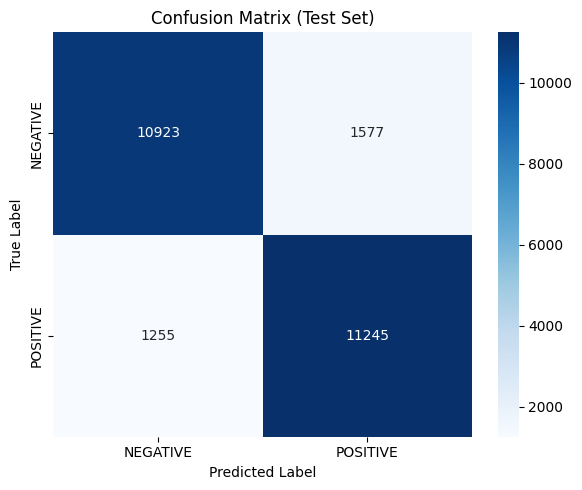

In [10]:
test_results = trainer.evaluate(eval_dataset=test_tokenized)
print("Test Results:")
for k, v in test_results.items():
    print(f"{k}: {v:.4f}")

# Get predictions for detailed metrics & confusion matrix
print("Running inference on test set for confusion matrix...")
predictions = trainer.predict(test_tokenized)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Compute detailed metrics
accuracy = accuracy_score(labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
cm = confusion_matrix(labels, preds)

print(f"\n Detailed Metrics (Test Set):")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["NEGATIVE", "POSITIVE"],
            yticklabels=["NEGATIVE", "POSITIVE"])
plt.title("Confusion Matrix (Test Set)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
print(f"Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")
plt.show()

## **5. Demo Inference**

The `predict_sentiment()` function demonstrates how the trained model can be used in practice. It loads the saved model and tokenizer, processes raw input texts (handling batching, truncation, and padding automatically), and returns human-readable predictions with confidence scores (softmax probabilities). The demo tests three cases: a clearly positive review, a clearly negative one, and a nuanced, neutral-like statement—highlighting both the model’s strengths (*high confidence on polar examples*) and limitations (*ambiguity on neutral/mixed sentiment*). This function serves as a template for integrating the model into APIs, dashboards, or batch-processing pipelines.

In [11]:
def predict_sentiment(texts, model_path=f"{OUTPUT_DIR}/final"):
    # Load model & tokenizer
    loaded_model = AutoModelForSequenceClassification.from_pretrained(model_path)
    loaded_tokenizer = AutoTokenizer.from_pretrained(model_path)
    loaded_model.eval()

    # Tokenize
    inputs = loaded_tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )

    # Predict
    with torch.no_grad():
        outputs = loaded_model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        preds = torch.argmax(logits, dim=-1)

    # Map to labels
    id2label = loaded_model.config.id2label
    results = []
    for i in range(len(texts)):
        pred_id = preds[i].item()
        results.append({
            "text": texts[i][:100] + "..." if len(texts[i]) > 100 else texts[i],
            "predicted_label": id2label[pred_id],
            "confidence": probs[i][pred_id].item()
        })
    return results

print("\n Demo Inference:")
sample_texts = [
    "This movie was absolutely fantastic! I loved every minute.",
    "Terrible acting and boring plot. Waste of time.",
    "It was okay, nothing special but not bad either."  # tricky neutral — model may lean pos/neg
]

predictions = predict_sentiment(sample_texts)
for i, pred in enumerate(predictions):
    print(f"\n{i+1}. Text: \"{pred['text']}\"")
    print(f"   → Predicted: {pred['predicted_label']} (Confidence: {pred['confidence']:.3f})")


 Demo Inference:

1. Text: "This movie was absolutely fantastic! I loved every minute."
   → Predicted: POSITIVE (Confidence: 0.994)

2. Text: "Terrible acting and boring plot. Waste of time."
   → Predicted: NEGATIVE (Confidence: 0.993)

3. Text: "It was okay, nothing special but not bad either."
   → Predicted: NEGATIVE (Confidence: 0.895)


### Practice 5: Try the whole pipeline for a dataset with more than 2 classes

In [15]:
# ─────────────────────────────────────────────────────────────
# Practice 5: Full pipeline for >2 classes (AG News – 4 classes)
# ─────────────────────────────────────────────────────────────

# 1. Load multi-class dataset
multi_dataset = load_dataset("ag_news")
print(multi_dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [16]:
# 2. Tokenizer & labels
multi_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def multi_tokenize(examples):
    return multi_tokenizer(examples["text"], truncation=True, padding=False, max_length=128)

multi_train = multi_dataset["train"].map(multi_tokenize, batched=True)
multi_test  = multi_dataset["test"].map(multi_tokenize,  batched=True)

multi_train.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
multi_test.set_format(type="torch",  columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [17]:
# 3. Model for 4 classes
multi_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label={0:"World", 1:"Sports", 2:"Business", 3:"Sci/Tech"},
    label2id={"World":0, "Sports":1, "Business":2, "Sci/Tech":3}
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
# 4. Training args (same as before)
multi_args = TrainingArguments(
    output_dir="./bert-agnews",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none"
)

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

In [20]:
# 5. Trainer (again)
multi_trainer = Trainer(
    model=multi_model,
    args=multi_args,
    train_dataset=multi_train,
    eval_dataset=multi_test,
    processing_class=multi_tokenizer,
    data_collator=DataCollatorWithPadding(multi_tokenizer),
    compute_metrics=compute_metrics   
)

multi_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.196700,0.176980,0.944868,0.944888,0.944967,0.944868
2,0.132900,0.190553,0.947763,0.947768,0.947805,0.947763
3,0.078600,0.231223,0.948816,0.948839,0.948998,0.948816


TrainOutput(global_step=22500, training_loss=0.14876190321180555, metrics={'train_runtime': 3388.2698, 'train_samples_per_second': 106.249, 'train_steps_per_second': 6.641, 'total_flos': 1.6999491211228032e+16, 'train_loss': 0.14876190321180555, 'epoch': 3.0})

Test Results (AG News):
eval_loss: 0.2312
eval_accuracy: 0.9488
eval_f1: 0.9488
eval_precision: 0.9490
eval_recall: 0.9488
eval_runtime: 21.6531
eval_samples_per_second: 350.9890
eval_steps_per_second: 21.9370
epoch: 3.0000

Running inference on test set for confusion matrix...

Detailed Metrics (Test Set - AG News):
Accuracy : 0.9488
Precision: 0.9490 (weighted)
Recall   : 0.9488 (weighted)
F1-score : 0.9488 (weighted)
Confusion matrix saved to ./bert-agnews/confusion_matrix.png


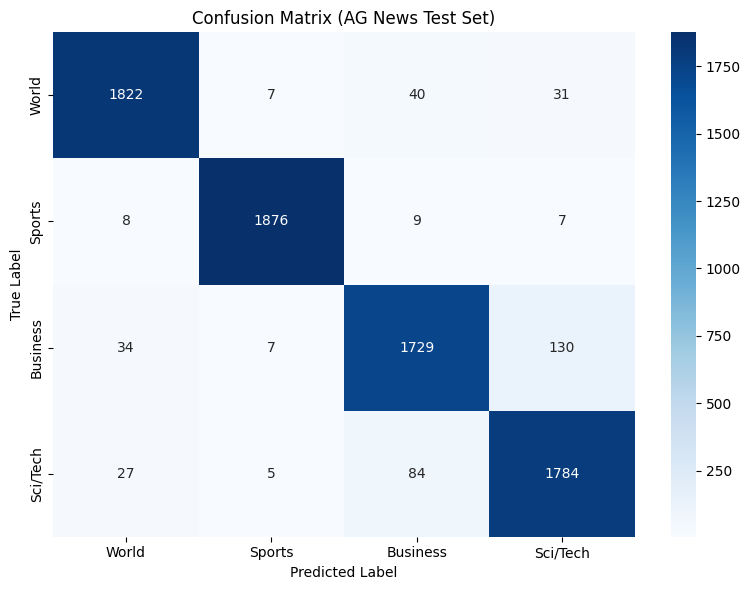

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Evaluate on the dedicated test set
test_results = multi_trainer.evaluate(eval_dataset=multi_test)
print("Test Results (AG News):")
for k, v in test_results.items():
    print(f"{k}: {v:.4f}")

# Get predictions for detailed metrics & confusion matrix
print("\nRunning inference on test set for confusion matrix...")
predictions = multi_trainer.predict(multi_test)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Compute detailed metrics (using 'weighted' for multi-class)
accuracy = accuracy_score(labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
cm = confusion_matrix(labels, preds)

print(f"\nDetailed Metrics (Test Set - AG News):")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f} (weighted)")
print(f"Recall   : {recall:.4f} (weighted)")
print(f"F1-score : {f1:.4f} (weighted)")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
class_names = ["World", "Sports", "Business", "Sci/Tech"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix (AG News Test Set)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("./bert-agnews/confusion_matrix.png", dpi=150)
print(f"Confusion matrix saved to ./bert-agnews/confusion_matrix.png")
plt.show()

In [25]:
def predict_category(texts, model_path="/kaggle/working/bert-agnews/checkpoint-22500"):
    # Load model & tokenizer
    loaded_model = AutoModelForSequenceClassification.from_pretrained(model_path)
    loaded_tokenizer = AutoTokenizer.from_pretrained(model_path)
    loaded_model.eval()

    # Tokenize
    inputs = loaded_tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Predict
    with torch.no_grad():
        outputs = loaded_model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        preds = torch.argmax(logits, dim=-1)

    # Map to labels
    id2label = loaded_model.config.id2label
    results = []
    for i in range(len(texts)):
        pred_id = preds[i].item()
        results.append({
            "text": texts[i][:100] + "..." if len(texts[i]) > 100 else texts[i],
            "predicted_label": id2label[pred_id],
            "confidence": probs[i][pred_id].item()
        })
    return results

print("\n--- AG News Demo Inference ---")
sample_headlines = [
    "The stock market rallied today as tech giants reported record earnings.",
    "The championship game went into overtime after a spectacular goal.",
    "NASA's new telescope has discovered a potentially habitable planet.",
    "Diplomatic talks have stalled following the border dispute."
]

predictions = predict_category(sample_headlines)
for i, pred in enumerate(predictions):
    print(f"\n{i+1}. Headline: \"{pred['text']}\"")
    print(f"   → Predicted Category: {pred['predicted_label']} (Confidence: {pred['confidence']:.3f})")


--- AG News Demo Inference ---

1. Headline: "The stock market rallied today as tech giants reported record earnings."
   → Predicted Category: Business (Confidence: 0.966)

2. Headline: "The championship game went into overtime after a spectacular goal."
   → Predicted Category: Sports (Confidence: 0.861)

3. Headline: "NASA's new telescope has discovered a potentially habitable planet."
   → Predicted Category: Sci/Tech (Confidence: 0.954)

4. Headline: "Diplomatic talks have stalled following the border dispute."
   → Predicted Category: World (Confidence: 0.997)


### **Bonus**

Implement full pipeline for token-level classification using huggingface transformers library

---
**Note:** This notebook is part of a Deep Learning assignment designed and prepared by [Mahdi Golizadeh](mailto:mahdi.golizadeh@gmail.com).